# CDOM Spectral Slope Processing - July 2009
## Using Mannino et al. Algorithm

This notebook calculates CDOM spectral slopes for July 2009 (matching the time period in apply_dbscan_model.ipynb) using the Mannino et al. Multiple Linear Regression (MLR) algorithm.

**Time Period:** July 1-31, 2009

**Algorithm Reference:** 
Mannino, A., et al. "Algorithm development and validation for satellite-derived distributions of DOC and CDOM in the U.S. Middle Atlantic Bight."

**Available Spectral Slopes:**
- **S_275:295**: Ln[S_275:295] = -3.258 + 0.336 × Ln[Rrs(443)] - 0.279 × Ln[Rrs(547)]
- **S_300:600**: Ln[S_300:600] = -3.640 + 0.186 × Ln[Rrs(443)] - 0.146 × Ln[Rrs(547)]

## 1. Library Imports

In [10]:
# Import essential libraries
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import binned_statistic_2d
import xarray as xr
import cmocean

import sys
sys.dont_write_bytecode = True
sys.path.append(os.path.abspath(".."))

# Import custom pipeline components
import importlib
from pipelines import l2_pipeline
importlib.reload(l2_pipeline)
from pipelines.l2_pipeline import L2DatasetLoader, GPUDataExtractor, SelectiveInterpolator

# Suppress RuntimeWarnings
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Configuration and Constants

In [11]:
# Time period configuration (matching apply_dbscan_model.ipynb)
apply_year = 2009
apply_start = '2009-07-01'
apply_end = '2009-07-31'

# MLR Coefficients for S_275:295 (using Rrs_443 and Rrs_547)
# Ln[S_275:295] = -3.258 + 0.336 × Ln[Rrs(443)] - 0.279 × Ln[Rrs(547)]
S275_295_COEFFS = {
    'B0': -3.258,    # Constant
    'B1': 0.336,     # Coefficient for Ln[Rrs(443)]
    'B2': -0.279     # Coefficient for Ln[Rrs(547)]
}

# MLR Coefficients for S_300:600 (using Rrs_443 and Rrs_547)
# Ln[S_300:600] = -3.640 + 0.186 × Ln[Rrs(443)] - 0.146 × Ln[Rrs(547)]
S300_600_COEFFS = {
    'B0': -3.640,    # Constant
    'B1': 0.186,     # Coefficient for Ln[Rrs(443)]
    'B2': -0.146     # Coefficient for Ln[Rrs(547)]
}

# Select which spectral slope to calculate
SLOPE_TYPE = 'S300_600'  # Options: 'S275_295' or 'S300_600'

# Geographical Bounding Box (matching apply_dbscan_model.ipynb EXACTLY)
# These bounds are loaded from the trained DBSCAN model
lon_min, lon_max = -94.0, -88.0
lat_min, lat_max = 27.5, 30.5

# Binning parameters (matching DBSCAN model grid)
lat_bins = 150
lon_bins = 300

# L2 RRS Data Configuration
data_dir_l2_rrs = rf"E:\satdata\Texas Louisiana Shelf_{apply_year}-06-01_{apply_year}-11-30"
rrs_vars_list = ['Rrs_443', 'Rrs_547']  # Required wavelengths for Mannino et al.
rrs_data_group = 'geophysical_data'

print(f"Configuration loaded for time period: {apply_start} to {apply_end}")
print(f"CDOM slope type: {SLOPE_TYPE}")
print(f"Data directory: {data_dir_l2_rrs}")

Configuration loaded for time period: 2009-07-01 to 2009-07-31
CDOM slope type: S300_600
Data directory: E:\satdata\Texas Louisiana Shelf_2009-06-01_2009-11-30


## 3. Search and Load L2 RRS Data Files

In [12]:
# Search for NetCDF files recursively
nc_files_rrs = glob.glob(os.path.join(data_dir_l2_rrs, '**', '*.nc'), recursive=True)

if not nc_files_rrs:
    print(f"⚠ Warning: No .nc files found in {data_dir_l2_rrs}")
else:
    print(f"Found {len(nc_files_rrs)} L2 RRS files in directory")
    
    # Filter files by date range
    import pandas as pd
    filtered_files = []
    
    for file_path in nc_files_rrs:
        filename = os.path.basename(file_path)
        try:
            # Extract date from filename (typical MODIS format: AQUA_MODIS.YYYYMMDD...)
            if 'AQUA_MODIS' in filename or 'MODIS' in filename:
                parts = filename.split('.')
                if len(parts) > 1:
                    date_str = parts[1][:8]
                    file_date = pd.to_datetime(date_str, format='%Y%m%d')
                    if pd.Timestamp(apply_start) <= file_date <= pd.Timestamp(apply_end):
                        filtered_files.append(file_path)
        except:
            continue
    
    nc_files_rrs = filtered_files
    print(f"Filtered to {len(nc_files_rrs)} files for period {apply_start} to {apply_end}")

Found 284 L2 RRS files in directory
Filtered to 50 files for period 2009-07-01 to 2009-07-31


## 4. Load RRS Datasets

In [13]:
# Load L2 RRS datasets
datasets_rrs = []
if nc_files_rrs:
    try:
        loader_rrs = L2DatasetLoader(variables=rrs_vars_list, group=rrs_data_group)
        datasets_rrs = loader_rrs.load_multiple(nc_files_rrs)
        print(f"✓ Successfully loaded {len(datasets_rrs)} L2 RRS datasets")
    except Exception as e:
        print(f"❌ Error loading L2 RRS datasets: {e}")
else:
    print("No L2 RRS files found to load")

# Initialize placeholder variables
lon_rrs_flat, lat_rrs_flat, rrs_vars_data_flat = np.array([]), np.array([]), {var: np.array([]) for var in rrs_vars_list}

✓ Successfully loaded 50 L2 RRS datasets


## 5. GPU Data Extraction

In [14]:
# Extract L2 RRS data using GPU
if datasets_rrs:
    try:
        extractor_rrs = GPUDataExtractor(variables=rrs_vars_list)
        lon_rrs_flat, lat_rrs_flat, rrs_vars_data_flat = extractor_rrs.extract(datasets_rrs)
        print(f"✓ L2 RRS data extraction complete: {len(lon_rrs_flat)} data points extracted")
        
        for var in rrs_vars_list:
            if var not in rrs_vars_data_flat or rrs_vars_data_flat[var].size == 0:
                print(f"⚠ Warning: RRS variable '{var}' not found or empty")
                if var not in rrs_vars_data_flat:
                    rrs_vars_data_flat[var] = np.array([])
    except Exception as e:
        print(f"❌ Error during L2 RRS data extraction: {e}")
        lon_rrs_flat, lat_rrs_flat, rrs_vars_data_flat = np.array([]), np.array([]), {var: np.array([]) for var in rrs_vars_list}
else:
    print("No L2 RRS datasets loaded, skipping extraction")

✓ L2 RRS data extraction complete: 14569607 data points extracted


## 6. Calculate CDOM Spectral Slope using Mannino et al. Algorithm

In [15]:
# Initialize final variables
cdom_slope_values = np.array([])

# Perform calculations only if RRS data was extracted
if lon_rrs_flat.size > 0 and rrs_vars_data_flat:
    all_lon_rrs = lon_rrs_flat
    all_lat_rrs = lat_rrs_flat

    # Extract the required RRS data (443 nm and 547 nm)
    rrs_443 = rrs_vars_data_flat.get('Rrs_443', np.array([]))
    rrs_547 = rrs_vars_data_flat.get('Rrs_547', np.array([]))
    
    # Check if both wavelengths are available and have correct shape
    if (rrs_443.size > 0 and rrs_547.size > 0 and 
        rrs_443.shape == all_lon_rrs.shape and rrs_547.shape == all_lon_rrs.shape):
        
        # Initialize slope values
        cdom_slope_values = np.full(all_lon_rrs.shape, np.nan)
        
        # Create mask for valid data (no NaNs and positive values)
        valid_mask = (~np.isnan(rrs_443) & ~np.isnan(rrs_547) & 
                     (rrs_443 > 0) & (rrs_547 > 0))
        
        if np.any(valid_mask):
            # Get the coefficients for the selected slope type
            if SLOPE_TYPE == 'S275_295':
                coeffs = S275_295_COEFFS
                slope_name = "S_275:295"
            elif SLOPE_TYPE == 'S300_600':
                coeffs = S300_600_COEFFS
                slope_name = "S_300:600"
            else:
                print(f"Error: Unknown slope type '{SLOPE_TYPE}'. Using S_300:600 as default.")
                coeffs = S300_600_COEFFS
                slope_name = "S_300:600"
            
            # Apply Mannino et al. MLR algorithm
            # Ln[S] = B0 + B1 × Ln[Rrs(443)] + B2 × Ln[Rrs(547)]
            ln_rrs_443 = np.log(rrs_443[valid_mask])
            ln_rrs_547 = np.log(rrs_547[valid_mask])
            
            ln_slope = (coeffs['B0'] + 
                       coeffs['B1'] * ln_rrs_443 + 
                       coeffs['B2'] * ln_rrs_547)
            
            # Convert back to linear space: S = exp(Ln[S])
            slope_values_valid = np.exp(ln_slope)
            
            # Assign back to the full array
            cdom_slope_values[valid_mask] = slope_values_valid
            
            print(f"✓ CDOM spectral slope calculation complete using Mannino et al. algorithm for {slope_name}")
            valid_slopes = cdom_slope_values[~np.isnan(cdom_slope_values)]
            if len(valid_slopes) > 0:
                print(f"  Min: {np.min(valid_slopes):.6f} nm⁻¹, Max: {np.max(valid_slopes):.6f} nm⁻¹")
                print(f"  Mean: {np.mean(valid_slopes):.6f} nm⁻¹, Std: {np.std(valid_slopes):.6f} nm⁻¹")
                print(f"  Valid pixels: {len(valid_slopes):,}")
            else:
                print("⚠ CDOM spectral slope calculation resulted in all NaNs")
        else:
            print("⚠ No valid data points found for CDOM spectral slope calculation")
    else:
        missing_vars = []
        if rrs_443.size == 0: missing_vars.append('Rrs_443')
        if rrs_547.size == 0: missing_vars.append('Rrs_547')
        if missing_vars:
            print(f"⚠ Skipping CDOM calculation: Missing variables {missing_vars}")
        else:
            print("⚠ Skipping CDOM calculation: Shape mismatch in RRS data")

    # Filter data for CDOM spectral slope
    valid_rrs_mask = ~np.isnan(all_lon_rrs) & ~np.isnan(all_lat_rrs) & ~np.isnan(cdom_slope_values)
    final_lon_rrs = all_lon_rrs[valid_rrs_mask]
    final_lat_rrs = all_lat_rrs[valid_rrs_mask]
    final_cdom_slope_rrs = cdom_slope_values[valid_rrs_mask]
    print(f"  Filtered to {len(final_lon_rrs):,} valid data points for binning")

else:
    print("⚠ Skipping CDOM processing: No L2 RRS data extracted")
    final_lon_rrs, final_lat_rrs, final_cdom_slope_rrs = np.array([]), np.array([]), np.array([])

✓ CDOM spectral slope calculation complete using Mannino et al. algorithm for S_300:600
  Min: 0.004416 nm⁻¹, Max: 0.078555 nm⁻¹
  Mean: 0.026125 nm⁻¹, Std: 0.002862 nm⁻¹
  Valid pixels: 14,535,980
  Filtered to 14,535,980 valid data points for binning
  Mean: 0.026125 nm⁻¹, Std: 0.002862 nm⁻¹
  Valid pixels: 14,535,980
  Filtered to 14,535,980 valid data points for binning


## 7. Clip and Bin CDOM Spectral Slope Data

In [16]:
# Initialize binned data variables
binned_cdom_slope = np.array([[]])
lon_grid, lat_grid = None, None
lat_edges, lon_edges = None, None

# Binning for CDOM Spectral Slope
if final_lon_rrs.size > 0:
    # Clip to bounding box
    clip_mask_rrs = (
        (final_lon_rrs >= lon_min) & (final_lon_rrs <= lon_max) &
        (final_lat_rrs >= lat_min) & (final_lat_rrs <= lat_max)
    )
    clipped_lon_rrs = final_lon_rrs[clip_mask_rrs]
    clipped_lat_rrs = final_lat_rrs[clip_mask_rrs]
    clipped_cdom_slope_rrs = final_cdom_slope_rrs[clip_mask_rrs]
    print(f"Clipped to bounding box: {len(clipped_lon_rrs):,} points remaining")

    if clipped_lon_rrs.size > 0:
        # Perform 2D binning
        binned_cdom_slope, lat_edges_temp, lon_edges_temp, _ = binned_statistic_2d(
            clipped_lat_rrs, clipped_lon_rrs, clipped_cdom_slope_rrs,
            statistic='mean', bins=[lat_bins, lon_bins], 
            range=[[lat_min, lat_max], [lon_min, lon_max]]
        )
        
        # Store edges for plotting
        lat_edges = lat_edges_temp
        lon_edges = lon_edges_temp
        
        # Create bin centers
        lon_grid, lat_grid = np.meshgrid(
            lon_edges_temp[:-1] + np.diff(lon_edges_temp)/2, 
            lat_edges_temp[:-1] + np.diff(lat_edges_temp)/2
        )
        
        valid_bins = np.sum(~np.isnan(binned_cdom_slope))
        print(f"✓ 2D binning complete: {valid_bins:,} valid bins out of {lat_bins}×{lon_bins}")
    else:
        print("⚠ No data points within bounding box to bin")
else:
    print("⚠ No valid CDOM spectral slope data to clip or bin")

Clipped to bounding box: 479,044 points remaining
✓ 2D binning complete: 33,272 valid bins out of 150×300


## 8. Selective NaN Interpolation

In [17]:
# Initialize interpolated data variable
cdom_slope_selective_interp = np.array([[]])
interpolation_threshold = 128  # Regions with fewer connected NaN bins than this will be interpolated

# Interpolation for CDOM Spectral Slope
if binned_cdom_slope.shape[0] > 0 and binned_cdom_slope.shape[1] > 0 and lat_edges is not None and lon_edges is not None:
    cdom_slope_selective_interp = SelectiveInterpolator.interpolate(
        binned_cdom_slope, lat_edges, lon_edges, threshold=interpolation_threshold
    )
    
    before_nans = np.sum(np.isnan(binned_cdom_slope))
    after_nans = np.sum(np.isnan(cdom_slope_selective_interp))
    filled = before_nans - after_nans
    
    print(f"✓ Selective NaN interpolation complete (threshold: {interpolation_threshold} bins)")
    print(f"  Filled {filled:,} bins ({100*filled/binned_cdom_slope.size:.1f}% of grid)")
else:
    print("⚠ No binned CDOM spectral slope data available for selective interpolation")

✓ Selective NaN interpolation complete (threshold: 128 bins)
  Filled 159 bins (0.4% of grid)


## 9. Visualize CDOM Spectral Slope

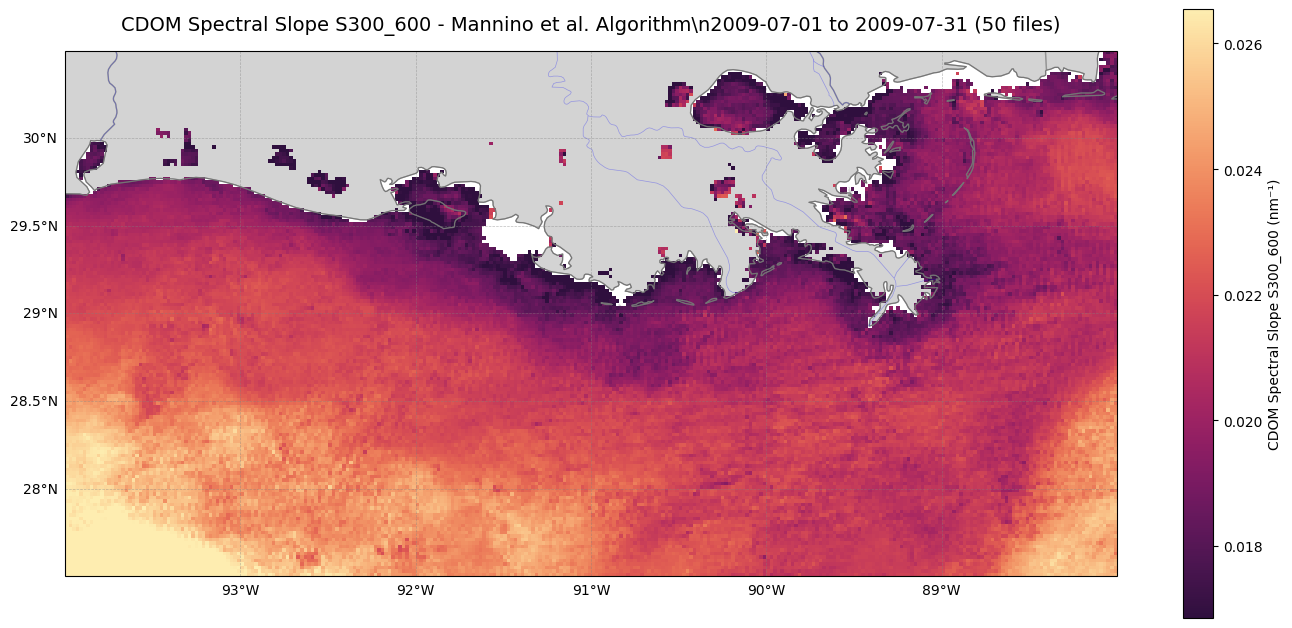

\n================================================================================
CDOM SPECTRAL SLOPE SUMMARY
  Time period: 2009-07-01 to 2009-07-31
  Slope type: S300_600
  Files processed: 50
  Valid data range: 0.016847 to 0.026549 nm⁻¹
  Mean: 0.021478 nm⁻¹
  Std: 0.002232 nm⁻¹


In [18]:
# Plot CDOM Spectral Slope
if (cdom_slope_selective_interp.shape[0] > 0 and cdom_slope_selective_interp.shape[1] > 0 and 
    lon_edges is not None and lat_edges is not None):
    
    fig = plt.figure(figsize=(14, 9))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    # Calculate color scale limits
    valid_cdom_slope_values = cdom_slope_selective_interp[~np.isnan(cdom_slope_selective_interp)]
    if valid_cdom_slope_values.size > 0:
        vmin_cdom = np.percentile(valid_cdom_slope_values, 2)
        vmax_cdom = np.percentile(valid_cdom_slope_values, 98)
        if vmin_cdom >= vmax_cdom:
            vmin_cdom = np.nanmin(valid_cdom_slope_values)
            vmax_cdom = np.nanmax(valid_cdom_slope_values)
        if vmin_cdom == vmax_cdom:
            vmin_cdom -= 0.001
            vmax_cdom += 0.001
    else:
        vmin_cdom, vmax_cdom = -0.01, 0.01

    # Plot using pcolormesh with cmocean matter colormap
    raster = ax.pcolormesh(
        lon_edges, lat_edges, cdom_slope_selective_interp,
        cmap=cmocean.cm.matter_r, shading='auto', 
        transform=ccrs.PlateCarree(),
        vmin=vmin_cdom, vmax=vmax_cdom
    )

    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='dimgray')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='dimgray')
    ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)
    ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue', alpha=0.3)

    # Add gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    # Colorbar and title
    slope_label = SLOPE_TYPE.replace('_', '_')
    cbar = plt.colorbar(raster, label=f'CDOM Spectral Slope {slope_label} (nm⁻¹)', shrink=0.7)
    
    num_files = len(nc_files_rrs) if nc_files_rrs else 0
    plt.title(f'CDOM Spectral Slope {slope_label} - Mannino et al. Algorithm\\n{apply_start} to {apply_end} ({num_files} files)', 
              fontsize=14, pad=15)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\\n{'='*80}")
    print("CDOM SPECTRAL SLOPE SUMMARY")
    print(f"{'='*80}")
    print(f"  Time period: {apply_start} to {apply_end}")
    print(f"  Slope type: {slope_label}")
    print(f"  Files processed: {num_files}")
    print(f"  Valid data range: {vmin_cdom:.6f} to {vmax_cdom:.6f} nm⁻¹")
    print(f"  Mean: {np.nanmean(valid_cdom_slope_values):.6f} nm⁻¹")
    print(f"  Std: {np.nanstd(valid_cdom_slope_values):.6f} nm⁻¹")
    print(f"{'='*80}")
else:
    print("⚠ No selectively interpolated CDOM spectral slope data to plot")